# Imports

In [93]:
import pandas as pd
import bs4
import requests
import re
import time
import numpy as np
import matplotlib.pyplot as plt 
import os
import PIL
import io
import random

from src.load_images import prepare_image_column, display_artwork_image
from src.gan_trainer import ArtGANTrainer

# Data

In [74]:
df = pd.read_csv('data/art_catalog.xlsx - catalog.csv')

In [75]:
df.head(2)

,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
0,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Venus and Adonis,1574-88,"Oil on canvas, 68 x 95 cm","Fogg Art Museum, Harvard University, Cambridge",https://www.wga.hu/html/a/aachen/adonis.html,painting,mythological,German,1601-1650
1,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",https://www.wga.hu/html/a/aachen/allegory.html,painting,mythological,German,1601-1650


In [76]:
painting_df = df[df['FORM'] == 'painting']
painting_df.head(2)

,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
0,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Venus and Adonis,1574-88,"Oil on canvas, 68 x 95 cm","Fogg Art Museum, Harvard University, Cambridge",https://www.wga.hu/html/a/aachen/adonis.html,painting,mythological,German,1601-1650
1,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",https://www.wga.hu/html/a/aachen/allegory.html,painting,mythological,German,1601-1650


In [77]:
painting_df = painting_df.drop(columns=['DATE', 'BORN-DIED', 'LOCATION', 'TECHNIQUE', 'URL', 'SCHOOL', 'TIMEFRAME'])

In [78]:
print(painting_df.shape)
painting_df.head(2)

(32438, 4)


,AUTHOR,TITLE,FORM,TYPE
0,"AACHEN, Hans von",Venus and Adonis,painting,mythological
1,"AACHEN, Hans von",Allegory,painting,mythological


In [79]:
painting_df.TYPE.value_counts(normalize=True)

TYPE
religious       0.416703
portrait        0.148283
landscape       0.126487
mythological    0.098711
genre           0.085455
still-life      0.043313
other           0.029903
historical      0.029071
interior        0.019607
study           0.002466
Name: proportion, dtype: float64

In [80]:
painting_df.TYPE.value_counts()

TYPE
religious       13517
portrait         4810
landscape        4103
mythological     3202
genre            2772
still-life       1405
other             970
historical        943
interior          636
study              80
Name: count, dtype: int64

In [81]:
painting_df.to_csv('data/full_painting_catalog.csv', index=False)

In [82]:
painting_df.iloc[0]

AUTHOR    AACHEN, Hans von
TITLE     Venus and Adonis
FORM              painting
TYPE          mythological
Name: 0, dtype: object

In [83]:
choosen_types_df = painting_df[painting_df['TYPE'].isin(['religious', 'portrait', 'landscape', 'mythological'])]
print(choosen_types_df.TYPE.value_counts())


TYPE
religious       13517
portrait         4810
landscape        4103
mythological     3202
Name: count, dtype: int64


In [84]:

choosen_types_df.to_csv('data/choosen_types_painting_catalog.csv', index=False)

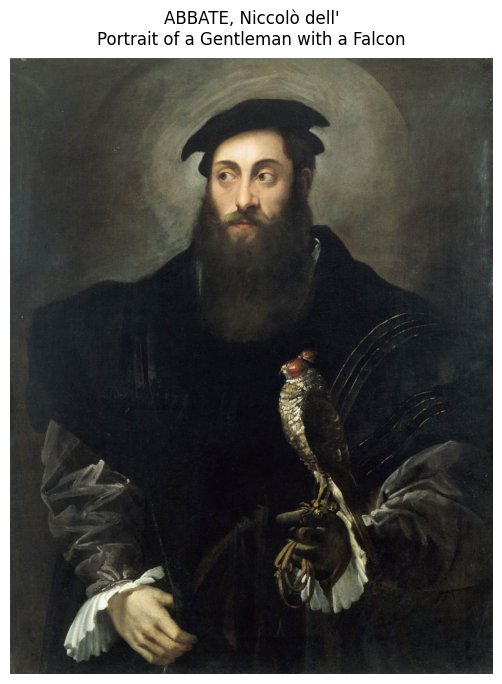

Loaded: /Users/julienrm/Workspace/M2/GANISME/app/data/img/ABBATE_Niccol_dell-Portrait_of_a_Gentleman_with_a_Falcon.jpg


In [85]:
# import re
# from PIL import Image
# import matplotlib.pyplot as plt

# def display_artwork_image(df, row_index):
#     """
#     Load and display an image from a DataFrame row.
    
#     Parameters:
#     -----------
#     df : pandas.DataFrame
#         DataFrame containing AUTHOR and TITLE columns
#     row_index : int
#         Index of the row to display
#     """
#     # Get author and title from the row
#     author = df.loc[row_index, 'AUTHOR']
#     title = df.loc[row_index, 'TITLE']
    
#     # Format author: replace non-alphanumeric chars (except hyphens) with underscores
#     # Keep hyphens as is, collapse multiple underscores into one
#     author_formatted = re.sub(r'[^a-zA-Z0-9\-]+', '_', author)
#     author_formatted = re.sub(r'_+', '_', author_formatted)  # Collapse multiple underscores
#     author_formatted = author_formatted.strip('_')  # Remove leading/trailing underscores
    
#     # Format title: same rules as author
#     title_formatted = re.sub(r'[^a-zA-Z0-9\-]+', '_', title)
#     title_formatted = re.sub(r'_+', '_', title_formatted)  # Collapse multiple underscores
#     title_formatted = title_formatted.strip('_')  # Remove leading/trailing underscores
    
#     # Construct filename
#     filename = f"data/img/{author_formatted}-{title_formatted}.jpg"
    
#     try:
#         # Load and display the image
#         img = Image.open(filename)
#         plt.figure(figsize=(10, 8))
#         plt.imshow(img)
#         plt.axis('off')
#         plt.title(f"{author}\n{title}", fontsize=12, pad=10)
#         plt.show()
        
#         print(f"Loaded: {filename}")
        
#     except FileNotFoundError:
#         print(f"Image not found: {filename}")
#         print(f"Author: {author} -> {author_formatted}")
#         print(f"Title: {title} -> {title_formatted}")
#     except Exception as e:
#         print(f"Error loading image: {e}")

# Example usage:
# display_artwork_image(df, 0)  # Display first row
# display_artwork_image(df, 42)  # Display row at index 42

# Example usage:
# display_artwork_image(df, 0)  # Display first row
display_artwork_image(df, 42)  # Display row at index 42

In [87]:
processed_painting_df = prepare_image_column(painting_df, "IMAGE", "resize_64")

Transform 'resize_64' processed 31062/32438 images.
Dropped 1376 rows due to missing or unreadable images.


In [88]:
processed_painting_df.head(2)

,AUTHOR,TITLE,FORM,TYPE,IMAGE
0,"AACHEN, Hans von",Venus and Adonis,painting,mythological,"[[[0.2627451, 0.2509804, 0.19215687], [0.23137..."
1,"AACHEN, Hans von",Allegory,painting,mythological,"[[[0.23137255, 0.24313726, 0.18039216], [0.215..."


In [ ]:
# ArtGANTrainer(processed_painting_df, 'TYPE', 'IMAGE', (64, 64, 3), batch_size=32, latent_dim=100)

In [ ]:
    # df_proc = prepare_image_column(df, "img_28", "28x28")
    # images = torch.from_numpy(
    #     np.stack(df_proc["img_28"].values)  # shape: (N, H, W, C)
    # ).permute(0, 3, 1, 2)  # -> (N, C, H, W)

In [94]:
import torch
from torch.utils.data import TensorDataset, DataLoader

images = torch.from_numpy(
    np.stack(processed_painting_df["IMAGE"].to_numpy())
).permute(0, 3, 1, 2)            # (N, C, H, W) = (N, 3, 64, 64)

dataset = TensorDataset(images)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

In [95]:
trainer = ArtGANTrainer(
    mode="basic",
    image_size=64,
    channels=3,
    latent_dim=128,
    fid_every=5,      # set >epochs to skip if torchmetrics missing
    fid_samples=256,
)

In [96]:
history = trainer.train(dataloader, epochs=50, lr=2e-4)
trainer.plot_history()

[Epoch 1/50] D_loss: 1.0707 G_loss: 1.6951 FID: nan Inception: nan
[Epoch 2/50] D_loss: 1.2103 G_loss: 1.2845 FID: nan Inception: nan
[Epoch 3/50] D_loss: 1.2695 G_loss: 1.1366 FID: nan Inception: nan
[Epoch 4/50] D_loss: 1.2848 G_loss: 1.1830 FID: nan Inception: nan


KeyboardInterrupt: 

In [ ]:
samples = trainer.sample(16).cpu()
grid = (samples + 1) / 2  # back to [0,1] for matplotlib

In [ ]:
# 1) Load & resize as 28×28 to keep the basic GAN fast


    dataset = TensorDataset(images)
    dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)
  - Train the “basic” mode:

    trainer = ArtGANTrainer(
        mode="basic",
        image_size=28,
        channels=3,
        latent_dim=128,
        fid_every=5,     # skip or raise if torchmetrics unavailable
        fid_samples=256, # optional
    )

    history = trainer.train(dataloader, epochs=50, lr=2e-4)
    trainer.plot_history()
  - Generate samples right away:

    samples = trainer.sample(16).cpu()  # in [-1, 1]
    grid = (samples + 1) / 2            # back to [0, 1] for plotting